<a href="https://colab.research.google.com/github/katholevidya07/transaction-fraud-detection/blob/main/transaction-fraud-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [2]:
import os

print(os.listdir())

['.config', 'creditcard.csv', 'sample_data']


In [3]:
import pandas as pd

file = "creditcard.csv"

# Read only the first 10,000 rows
df_sample = pd.read_csv(file, nrows=10000)

print("Number of columns:", len(df_sample.columns))
print("\nColumn names:")
print(df_sample.columns.tolist())

Number of columns: 31

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [4]:
df_sample.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print("Missing values in each column:")
print(df_sample.isnull().sum())

Missing values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [6]:


print("Duplicate rows:", df_sample.duplicated().sum())

Duplicate rows: 42


In [7]:
print(df_sample.dtypes)

Time        int64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [8]:
chunksize = 50000

In [9]:
chunks = pd.read_csv(file, chunksize=chunksize)

In [10]:
df = next(chunks)

In [11]:
df.shape

(50000, 31)

In [12]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [13]:
df.duplicated().sum()

np.int64(220)

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [17]:
df.isnull().sum().sum()

np.int64(0)

In [18]:
df.dtypes

,0
Time,int64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [19]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [20]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,49780.000000,49780.000000,49780.000000,49780.000000,49780.000000,49780.000000,49780.000000,49780.000000,49780.000000,49780.000000,...,49780.000000,49780.000000,49780.000000,49780.000000,49780.000000,49780.000000,49780.000000,49780.000000,49780.000000,49780.000000
mean,28919.594757,-0.237298,0.005462,0.693521,0.183052,-0.256239,0.104050,-0.119348,0.052706,0.117690,...,-0.029910,-0.106188,-0.040097,0.008450,0.135404,0.021396,0.006060,0.004127,93.484539,0.002973
std,13112.602734,1.880729,1.626821,1.507822,1.400628,1.412463,1.312357,1.282352,1.219102,1.212611,...,0.730826,0.637628,0.590647,0.594404,0.439118,0.501501,0.383821,0.334366,253.440407,0.054445
min,0.000000,-56.407510,-72.715728,-32.965346,-5.172595,-42.147898,-26.160506,-26.548144,-41.484823,-9.283925,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.577118,-8.567638,-9.617915,0.000000,0.000000
25%,21880.000000,-0.988124,-0.567576,0.217019,-0.723496,-0.866465,-0.636585,-0.604515,-0.146899,-0.616181,...,-0.231322,-0.529328,-0.179039,-0.321917,-0.128515,-0.330223,-0.062972,-0.006637,7.680000,0.000000
50%,33467.000000,-0.242538,0.076726,0.796153,0.187934,-0.288135,-0.151839,-0.076649,0.058032,0.007678,...,-0.068137,-0.081315,-0.051720,0.062455,0.175255,-0.071598,0.009037,0.022186,25.030000,0.000000
75%,38974.000000,1.155779,0.729179,1.431050,1.065577,0.283628,0.493446,0.424987,0.331046,0.815324,...,0.108337,0.308386,0.078620,0.401671,0.422140,0.300112,0.083914,0.076280,85.680000,0.000000
max,44299.000000,1.960497,18.183626,4.101716,16.491217,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,17.297845,4.014444,5.525093,3.517346,11.135740,33.847808,12910.930000,1.000000


In [21]:
total_rows = 0

for chunk in pd.read_csv(file, chunksize=50000):
    total_rows += len(chunk)

print("Total rows:", total_rows)

Total rows: 284807


In [22]:
duplicate_count = 0

for chunk in pd.read_csv(file, chunksize=50000):
    duplicate_count += chunk.duplicated().sum()

print("Duplicate rows found:", duplicate_count)

Duplicate rows found: 1081


In [23]:
output_file = "creditcard_no_duplicates.csv"

first_chunk = True

for chunk in pd.read_csv(file, chunksize=50000):
    chunk = chunk.drop_duplicates()

    chunk.to_csv(
        output_file,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False

print("Done! Duplicate rows removed.")

Done! Duplicate rows removed.


In [24]:
import os

print(os.path.exists("creditcard_no_duplicates.csv"))

True


In [25]:
df_clean = pd.read_csv("creditcard_no_duplicates.csv", nrows=10000)

In [26]:
df_clean.shape

(10000, 31)

In [27]:
df_clean.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [28]:

df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,10000.0,6015.927300,4503.360942,0.000000,2090.000000,4644.000000,10313.000000,15164.000000
V1,10000.0,-0.237010,1.516425,-27.670569,-1.010036,-0.369943,1.150932,1.960497
V2,10000.0,0.278067,1.305161,-34.607649,-0.210885,0.287520,0.900296,8.636214
V3,10000.0,0.907847,1.161115,-15.496222,0.414690,0.947367,1.606295,4.101716
V4,10000.0,0.265422,1.444019,-4.657545,-0.615265,0.219689,1.127894,10.463020
V5,10000.0,-0.046496,1.182458,-32.092129,-0.642582,-0.152093,0.369953,34.099309
V6,10000.0,0.131493,1.308863,-23.496714,-0.630609,-0.154453,0.499450,21.393069
V7,10000.0,-0.070269,1.076473,-26.548144,-0.541054,-0.053796,0.476163,34.303177
V8,10000.0,-0.062309,1.248165,-23.632502,-0.190495,0.012715,0.272243,5.060381
V9,10000.0,0.804530,1.155459,-6.329801,0.073152,0.809299,1.508029,10.392889


In [29]:
df_clean["Amount"].describe()

,Amount
count,10000.000000
mean,63.392095
std,184.682578
min,0.000000
25%,5.000000
50%,15.950000
75%,51.760000
max,7712.430000


In [30]:
df_clean["Amount"].min()

0.0

In [31]:
df_clean["Amount"].max()

7712.43

In [32]:
df_clean["Class"].value_counts()

,count
Class,
0,9962
1,38


In [33]:
df_clean["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.62
1,0.38


In [34]:
df_clean.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [35]:
df_clean.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

In [36]:
df_clean.columns = df_clean.columns.str.strip()

In [37]:
df_clean.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

In [38]:
df_clean["Class"].unique()

array([0, 1])

In [39]:
df_clean["Class"].value_counts()

,count
Class,
0,9962
1,38


In [40]:
df_clean["Time"].describe()

,Time
count,10000.000000
mean,6015.927300
std,4503.360942
min,0.000000
25%,2090.000000
50%,4644.000000
75%,10313.000000
max,15164.000000


In [41]:
df_clean["Time"].min()

0

In [42]:
df_clean["Time"].max()

15164

In [43]:
import os

print("Original file:", os.path.getsize("creditcard.csv") / (1024 * 1024), "MB")
print("Cleaned file:", os.path.getsize("creditcard_no_duplicates.csv") / (1024 * 1024), "MB")

Original file: 143.8415069580078 MB
Cleaned file: 142.84194469451904 MB


In [44]:
import pandas as pd

input_file = "creditcard.csv"
final_file = "creditcard_cleaned.csv"

seen = set()
first_chunk = True

In [45]:
for chunk in pd.read_csv(input_file, chunksize=50000):

    row_hashes = pd.util.hash_pandas_object(chunk, index=False)

    keep = ~row_hashes.isin(seen)

    cleaned_chunk = chunk[keep]

    seen.update(row_hashes[keep])

    cleaned_chunk.to_csv(
        final_file,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False

print("Final cleaning completed!")

Final cleaning completed!


In [46]:
import os

print(os.path.exists("creditcard_cleaned.csv"))

True


In [47]:
final_rows = 0

for chunk in pd.read_csv("creditcard_cleaned.csv", chunksize=50000):
    final_rows += len(chunk)

print("Final number of rows:", final_rows)

Final number of rows: 284807


In [48]:
df_final_sample = pd.read_csv("creditcard_cleaned.csv", nrows=10000)

print(df_final_sample.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [49]:
final_rows = 0

for chunk in pd.read_csv("creditcard_cleaned.csv", chunksize=50000):
    final_rows += len(chunk)

print("Final number of rows:", final_rows)

Final number of rows: 284807


In [50]:
df_check = pd.read_csv("creditcard_cleaned.csv")

print("Duplicate rows:", df_check.duplicated().sum())

Duplicate rows: 1081


In [51]:
df_check = df_check.drop_duplicates()

In [52]:
print("Rows after removing duplicates:", len(df_check))

Rows after removing duplicates: 283726


In [53]:
print("Duplicates remaining:", df_check.duplicated().sum())

Duplicates remaining: 0


In [54]:
df_check.to_csv("creditcard_cleaned_final.csv", index=False)

In [55]:
df_check.shape

(283726, 31)

In [56]:
df_check.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [57]:
df_check.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 

In [58]:
df_check.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [59]:
df_check.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [60]:
df_check['Class'].value_counts()

,count
Class,
0,283253
1,473


In [61]:
df_check.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


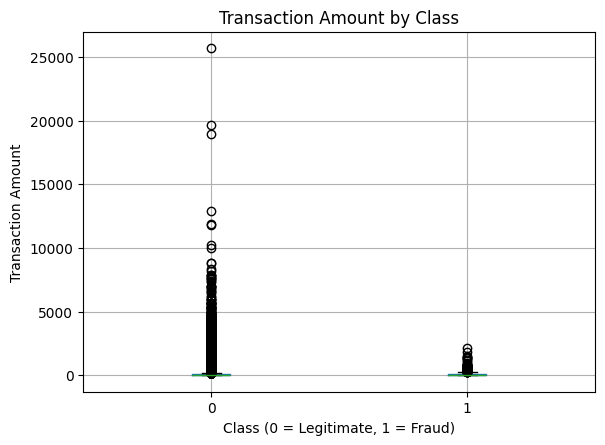

In [62]:
import matplotlib.pyplot as plt

df_check.boxplot(column='Amount', by='Class')

plt.title('Transaction Amount by Class')
plt.suptitle('')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Transaction Amount')
plt.show()

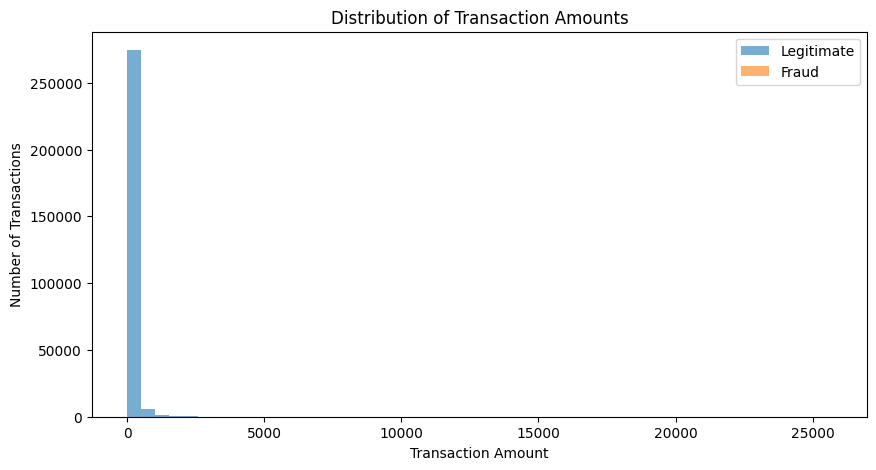

In [63]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_check[df_check['Class'] == 0]['Amount'],
    bins=50,
    alpha=0.6,
    label='Legitimate'
)

plt.hist(
    df_check[df_check['Class'] == 1]['Amount'],
    bins=50,
    alpha=0.6,
    label='Fraud'
)

plt.xlabel('Transaction Amount')
plt.ylabel('Number of Transactions')
plt.title('Distribution of Transaction Amounts')
plt.legend()
plt.show()

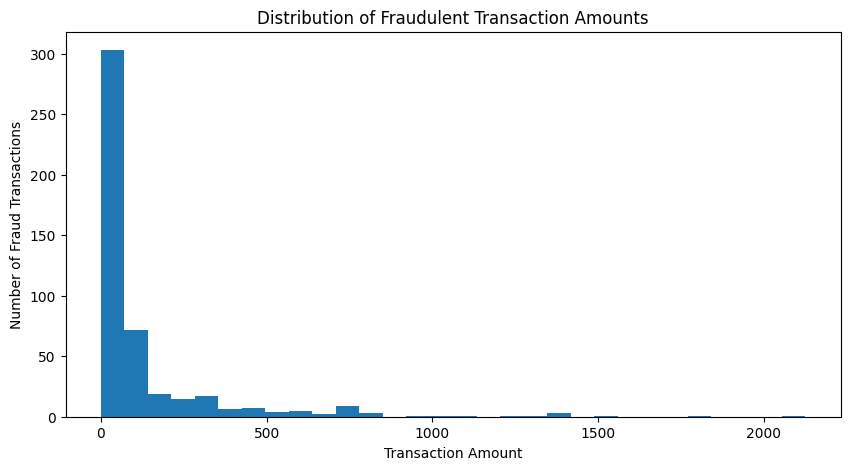

In [64]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_check[df_check['Class'] == 1]['Amount'],
    bins=30
)

plt.xlabel('Transaction Amount')
plt.ylabel('Number of Fraud Transactions')
plt.title('Distribution of Fraudulent Transaction Amounts')
plt.show()

In [65]:
df_check.groupby('Class')['Time'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,94835.058093,47475.550607,0.0,54233.0,84711.0,139308.0,172792.0
1,473.0,80450.513742,48636.179973,406.0,41203.0,73408.0,129095.0,170348.0


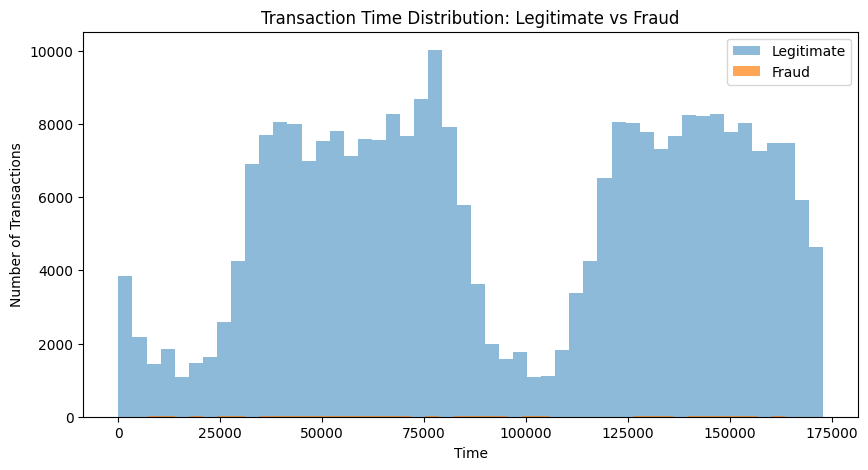

In [66]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_check[df_check['Class'] == 0]['Time'],
    bins=50,
    alpha=0.5,
    label='Legitimate'
)

plt.hist(
    df_check[df_check['Class'] == 1]['Time'],
    bins=50,
    alpha=0.7,
    label='Fraud'
)

plt.xlabel('Time')
plt.ylabel('Number of Transactions')
plt.title('Transaction Time Distribution: Legitimate vs Fraud')
plt.legend()
plt.show()

In [67]:
correlation = df_check.corr(numeric_only=True)['Class'].sort_values()

print(correlation)

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Class     1.000000
Name: Class, dtype: float64


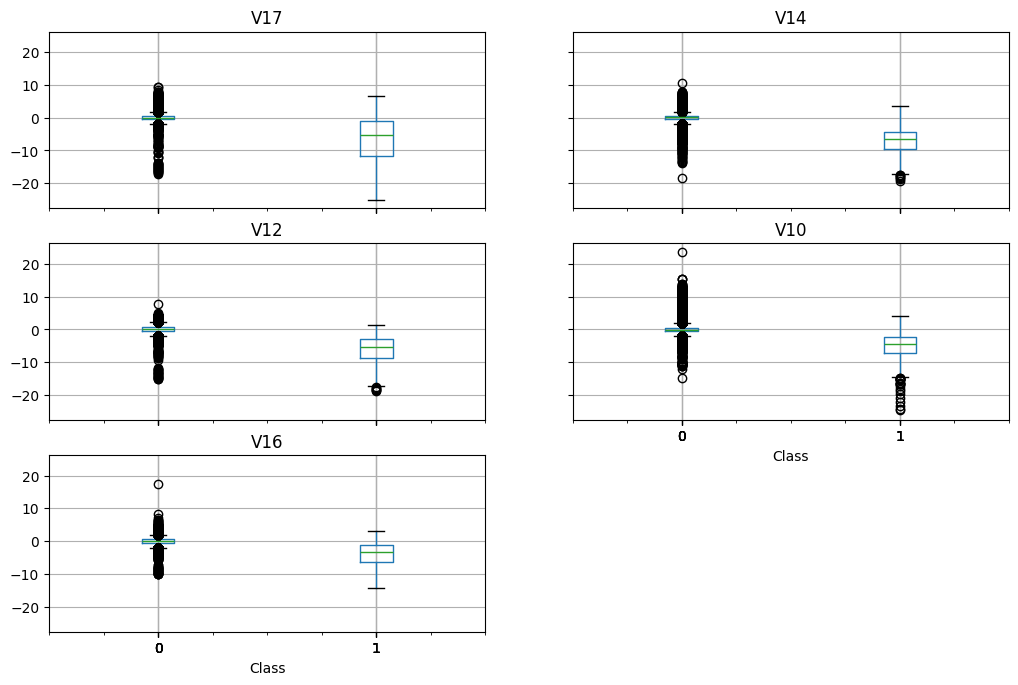

In [68]:
top_features = ['V17', 'V14', 'V12', 'V10', 'V16']

df_check.boxplot(
    column=top_features,
    by='Class',
    figsize=(12, 8)
)

plt.suptitle('')
plt.show()

In [69]:
X = df_check.drop('Class', axis=1)
y = df_check['Class']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (283726, 30)
Target: (283726,)


In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Fraud in training:", y_train.sum())
print("Fraud in testing:", y_test.sum())

Training data: (226980, 30)
Testing data: (56746, 30)
Fraud in training: 378
Fraud in testing: 95


In [71]:
print(df_check.shape)

(283726, 31)


In [73]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [74]:
import os

print("File exists:", os.path.exists(cleaned_path))

File exists: False


In [75]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print("Training data:", X_train_scaled.shape)
print("Testing data:", X_test_scaled.shape)

Features scaled successfully!
Training data: (226980, 30)
Testing data: (56746, 30)


In [76]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [77]:
y_pred = model.predict(X_test_scaled)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 56746


In [78]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



In [79]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[55262  1389]
 [   12    83]]


In [80]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9656548079701293


In [82]:
# Check our current dataset columns
print("Shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(i, "-", col)

print("\nData types:")
print(df.dtypes)

Shape: (49780, 31)

Columns:
1 - Time
2 - V1
3 - V2
4 - V3
5 - V4
6 - V5
7 - V6
8 - V7
9 - V8
10 - V9
11 - V10
12 - V11
13 - V12
14 - V13
15 - V14
16 - V15
17 - V16
18 - V17
19 - V18
20 - V19
21 - V20
22 - V21
23 - V22
24 - V23
25 - V24
26 - V25
27 - V26
28 - V27
29 - V28
30 - Amount
31 - Class

Data types:
Time        int64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [83]:
import numpy as np

# Create a copy so we don't accidentally damage the original cleaned data
df_fe = df.copy()

# Convert Time from seconds into hours
df_fe['Hour'] = (df_fe['Time'] / 3600) % 24

# Create time-of-day categories
df_fe['Time_of_Day'] = pd.cut(
    df_fe['Hour'],
    bins=[-1, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

# Log transformation of transaction amount
df_fe['Log_Amount'] = np.log1p(df_fe['Amount'])

# Display the new features
print(df_fe[['Time', 'Hour', 'Time_of_Day', 'Amount', 'Log_Amount', 'Class']].head())

print("\nNew shape:", df_fe.shape)

   Time      Hour Time_of_Day  Amount  Log_Amount  Class
0     0  0.000000       Night  149.62    5.014760      0
1     0  0.000000       Night    2.69    1.305626      0
2     1  0.000278       Night  378.66    5.939276      0
3     1  0.000278       Night  123.50    4.824306      0
4     2  0.000556       Night   69.99    4.262539      0

New shape: (49780, 34)


In [84]:
class_weight='balanced'

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Train Logistic Regression with balanced class weights
balanced_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

balanced_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_balanced = balanced_model.predict(X_test_scaled)
y_prob_balanced = balanced_model.predict_proba(X_test_scaled)[:, 1]

# Results
print("Classification Report:")
print(classification_report(y_test, y_pred_balanced))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_balanced))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

Confusion Matrix:
[[55262  1389]
 [   12    83]]
ROC-AUC Score: 0.9656548079701293


In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Random Forest with balanced class weights
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Random Forest - Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Random Forest - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("Random Forest - ROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_rf))

Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746

Random Forest - Confusion Matrix:
[[56649     2]
 [   28    67]]
Random Forest - ROC-AUC Score:
0.9246064314375461


In [87]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Train
xgb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("XGBoost - Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print("XGBoost - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("XGBoost - ROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_xgb))

XGBoost - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.73      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746

XGBoost - Confusion Matrix:
[[56647     4]
 [   26    69]]
XGBoost - ROC-AUC Score:
0.9708689120552524


In [88]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Use engineered numeric features
X_fe = df_fe.drop(columns=['Class', 'Time_of_Day'])
y_fe = df_fe['Class']

# Train-test split
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.20,
    stratify=y_fe,
    random_state=42
)

# Scale features
scaler_fe = StandardScaler()

X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

print("Training shape:", X_train_fe_scaled.shape)
print("Testing shape:", X_test_fe_scaled.shape)
print("Fraud in training:", y_train_fe.sum())
print("Fraud in testing:", y_test_fe.sum())

Training shape: (39824, 32)
Testing shape: (9956, 32)
Fraud in training: 118
Fraud in testing: 30


In [89]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# XGBoost with engineered features
xgb_fe_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Train
xgb_fe_model.fit(X_train_fe_scaled, y_train_fe)

# Predictions
y_pred_xgb_fe = xgb_fe_model.predict(X_test_fe_scaled)
y_prob_xgb_fe = xgb_fe_model.predict_proba(X_test_fe_scaled)[:, 1]

# Evaluation
print("XGBoost + Feature Engineering")
print("\nClassification Report:")
print(classification_report(y_test_fe, y_pred_xgb_fe))

print("Confusion Matrix:")
print(confusion_matrix(y_test_fe, y_pred_xgb_fe))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test_fe, y_prob_xgb_fe))

XGBoost + Feature Engineering

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9926
           1       0.97      0.93      0.95        30

    accuracy                           1.00      9956
   macro avg       0.98      0.97      0.97      9956
weighted avg       1.00      1.00      1.00      9956

Confusion Matrix:
[[9925    1]
 [   2   28]]

ROC-AUC Score:
0.9998723890120222


Top 15 Fraud Predictors:
   Feature  Importance
11     V11    0.601325
10     V10    0.096655
12     V12    0.078198
4       V4    0.026671
14     V14    0.024821
7       V7    0.013402
26     V26    0.012983
17     V17    0.012723
27     V27    0.011184
29  Amount    0.010153
6       V6    0.010137
3       V3    0.009312
2       V2    0.007267
21     V21    0.007061
20     V20    0.006012


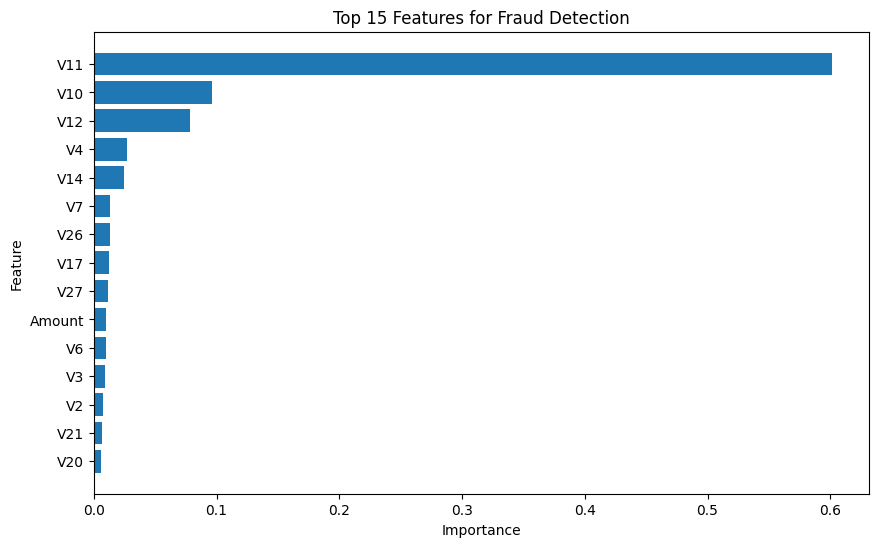

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_fe.columns,
    'Importance': xgb_fe_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top 15 Fraud Predictors:")
print(feature_importance.head(15))

# Plot top 15 features
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance.head(15)['Feature'][::-1],
    feature_importance.head(15)['Importance'][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for Fraud Detection")
plt.show()

In [91]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Balanced Logistic Regression',
        'Random Forest',
        'XGBoost',
        'XGBoost + Feature Engineering'
    ],
    'Precision': [
        0.06,
        0.06,
        0.97,
        0.95,
        0.97
    ],
    'Recall': [
        0.87,
        0.87,
        0.71,
        0.73,
        0.93
    ],
    'F1-Score': [
        0.11,
        0.11,
        0.82,
        0.82,
        0.95
    ],
    'ROC-AUC': [
        0.96565,
        0.96565,
        0.92461,
        0.97087,
        0.99987
    ]
})

comparison

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.06,0.87,0.11,0.96565
1,Balanced Logistic Regression,0.06,0.87,0.11,0.96565
2,Random Forest,0.97,0.71,0.82,0.92461
3,XGBoost,0.95,0.73,0.82,0.97087
4,XGBoost + Feature Engineering,0.97,0.93,0.95,0.99987


In [92]:
import numpy as np

df_check['Amount_log'] = np.log1p(df_check['Amount'])

print("New feature created successfully!")
print(df_check[['Amount', 'Amount_log']].head())

New feature created successfully!
   Amount  Amount_log
0  149.62    5.014760
1    2.69    1.305626
2  378.66    5.939276
3  123.50    4.824306
4   69.99    4.262539


In [93]:
print("New dataset shape:", df_check.shape)

New dataset shape: (283726, 32)


In [94]:
X = df_check.drop('Class', axis=1)
y = df_check['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (283726, 31)
y shape: (283726,)


In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)
print("Fraud in training:", y_train.sum())
print("Fraud in testing:", y_test.sum())

Training: (226980, 31)
Testing: (56746, 31)
Fraud in training: 378
Fraud in testing: 95


In [96]:
from sklearn.preprocessing import StandardScaler

scaler_new = StandardScaler()

X_train_scaled_new = scaler_new.fit_transform(X_train)
X_test_scaled_new = scaler_new.transform(X_test)

print("New features scaled successfully!")
print("Training data:", X_train_scaled_new.shape)
print("Testing data:", X_test_scaled_new.shape)

New features scaled successfully!
Training data: (226980, 31)
Testing data: (56746, 31)


In [97]:
from sklearn.linear_model import LogisticRegression

log_model_new = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_model_new.fit(X_train_scaled_new, y_train)

print("Improved Logistic Regression trained successfully!")

Improved Logistic Regression trained successfully!


In [98]:
y_pred_new = log_model_new.predict(X_test_scaled_new)

print("Predictions completed!")
print("Number of predictions:", len(y_pred_new))

Predictions completed!
Number of predictions: 56746


In [99]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred_new))

print("ROC-AUC Score:")
print(roc_auc_score(y_test, log_model_new.predict_proba(X_test_scaled_new)[:, 1]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_new))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.10        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

ROC-AUC Score:
0.9653817603442685
Confusion Matrix:
[[55246  1405]
 [   12    83]]


# Feature Engineering + Improved Logistic Regression
Created the Amount_log feature using log transformation.
Trained an improved Logistic Regression model with balanced class weights.

Results:
- Precision (Fraud): 0.06
- Recall (Fraud): 0.87
- F1-score (Fraud): 0.10
- ROC-AUC: 0.966

In [100]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [101]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions completed!")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions completed!
Number of predictions: 56746


In [102]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Random Forest ROC-AUC Score:")
rf_auc = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test)[:, 1]
)
print(rf_auc)

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.99      0.69      0.81        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746

Random Forest ROC-AUC Score:
0.935207349895807
Random Forest Confusion Matrix:
[[56650     1]
 [   29    66]]


# Random Forest Model

Trained a Random Forest classifier with balanced class weights.

Results:
- Precision (Fraud): 0.99
- Recall (Fraud): 0.69
- F1-score (Fraud): 0.81
- ROC-AUC: 0.935
- False Positives: 1
- Fraud Detected: 66 out of 95

In [103]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [0.06, 0.99],
    'Recall': [0.87, 0.69],
    'F1-Score': [0.10, 0.81],
    'ROC-AUC': [0.966, 0.935]
})

model_comparison

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.06,0.87,0.10,0.966
1,Random Forest,0.99,0.69,0.81,0.935


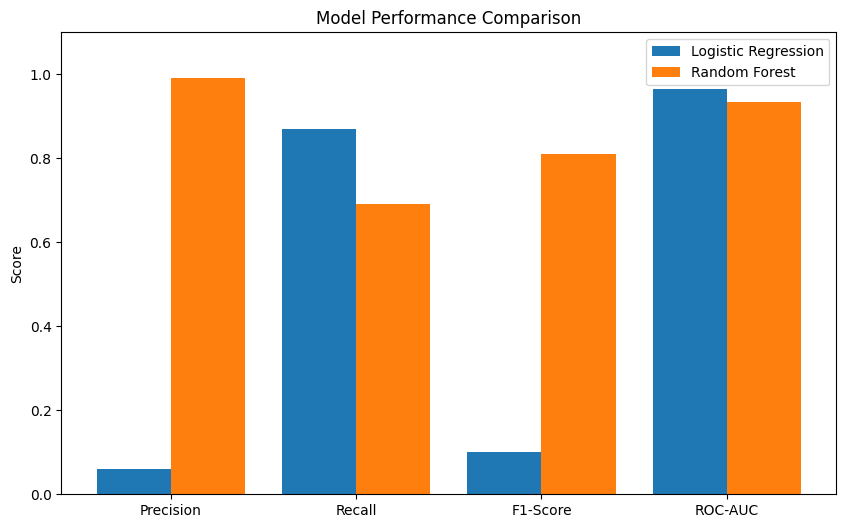

In [104]:
import matplotlib.pyplot as plt

metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = range(len(metrics))

plt.figure(figsize=(10, 6))

plt.bar(
    [i - 0.2 for i in x],
    model_comparison.iloc[0][metrics],
    width=0.4,
    label='Logistic Regression'
)

plt.bar(
    [i + 0.2 for i in x],
    model_comparison.iloc[1][metrics],
    width=0.4,
    label='Random Forest'
)

plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

In [105]:
from sklearn.ensemble import RandomForestClassifier

rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

print("Tuned Random Forest trained successfully!")

Tuned Random Forest trained successfully!


In [106]:
y_pred_tuned = rf_tuned.predict(X_test)

print("Tuned Random Forest predictions completed!")
print("Number of predictions:", len(y_pred_tuned))

Tuned Random Forest predictions completed!
Number of predictions: 56746


In [107]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, y_pred_tuned))

print("Tuned Random Forest ROC-AUC Score:")
tuned_auc = roc_auc_score(
    y_test,
    rf_tuned.predict_proba(X_test)[:, 1]
)
print(tuned_auc)

print("Tuned Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.74      0.80        95

    accuracy                           1.00     56746
   macro avg       0.94      0.87      0.90     56746
weighted avg       1.00      1.00      1.00     56746

Tuned Random Forest ROC-AUC Score:
0.9663197286432441
Tuned Random Forest Confusion Matrix:
[[56642     9]
 [   25    70]]


# Tuned Random Forest

Tuned the Random Forest using 200 trees, maximum depth of 12,
minimum samples split of 5, and balanced class weights.

Results:
- Precision (Fraud): 0.89
- Recall (Fraud): 0.74
- F1-score (Fraud): 0.80
- ROC-AUC: 0.966
- Fraud Detected: 70 out of 95
- False Positives: 9

Tuning improved fraud recall and ROC-AUC compared with the original
Random Forest model.

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_tuned.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top 10 Features:")
print(feature_importance.head(10))

Top 10 Features:
   Feature  Importance
14     V14    0.189822
10     V10    0.158120
12     V12    0.096891
4       V4    0.083120
11     V11    0.074322
17     V17    0.072952
3       V3    0.047445
16     V16    0.043558
7       V7    0.031905
9       V9    0.022099


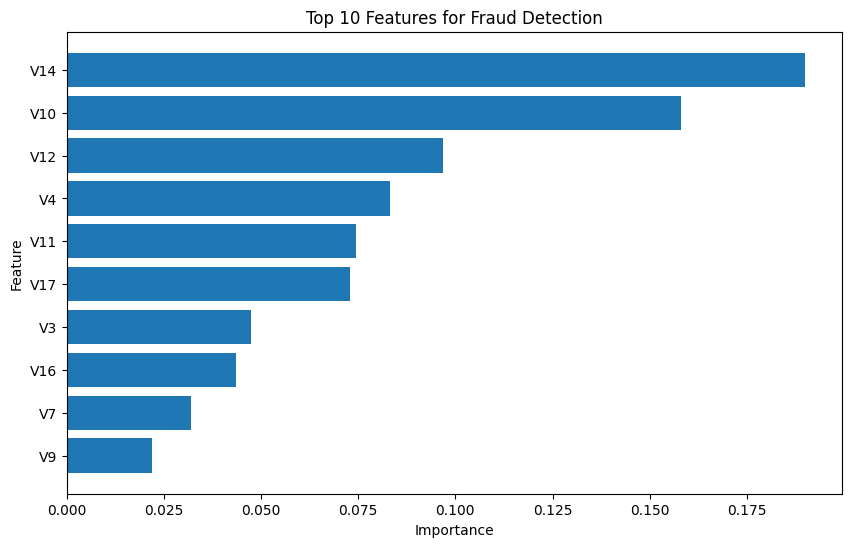

In [109]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Features for Fraud Detection')
plt.show()

# Feature Importance Analysis

The tuned Random Forest model was used to identify the most important
features for fraud detection.

Top features:
- V14
- V10
- V12
- V4
- V11
- V17
- V3
- V16
- V7
- V9

V14, V10, and V12 were the three most influential features according
to the Random Forest model.

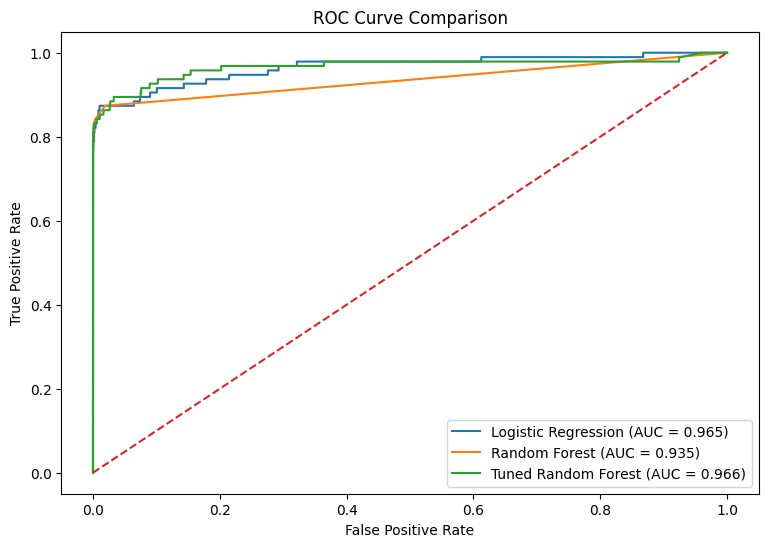

In [110]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Prediction probabilities
y_prob_log = log_model_new.predict_proba(X_test_scaled_new)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_tuned = rf_tuned.predict_proba(X_test)[:, 1]

# ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)

# Plot
plt.figure(figsize=(9, 6))

plt.plot(
    fpr_log, tpr_log,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.3f})'
)

plt.plot(
    fpr_rf, tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})'
)

plt.plot(
    fpr_tuned, tpr_tuned,
    label=f'Tuned Random Forest (AUC = {roc_auc_score(y_test, y_prob_tuned):.3f})'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# ROC Curve Analysis

The ROC curves were compared for Logistic Regression, Random Forest,
and Tuned Random Forest.

Results:
- Logistic Regression: ROC-AUC = 0.965
- Random Forest: ROC-AUC = 0.935
- Tuned Random Forest: ROC-AUC = 0.966

The Tuned Random Forest achieved the highest ROC-AUC score, indicating
strong overall discrimination between fraudulent and legitimate
transactions.

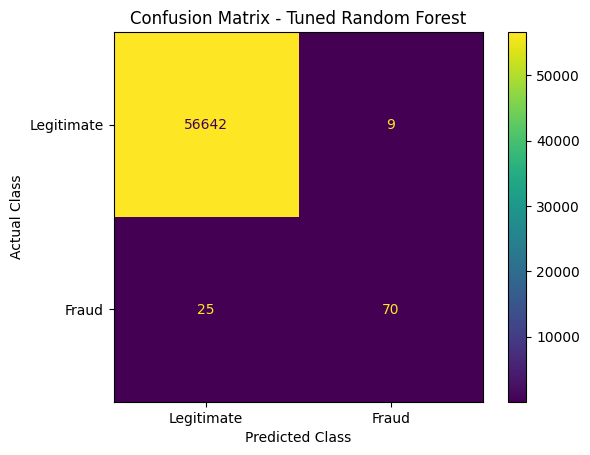

In [111]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=['Legitimate', 'Fraud']
)

disp.plot()

plt.title('Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

# Confusion Matrix Analysis

The Tuned Random Forest correctly classified 56,642 legitimate
transactions and 70 fraudulent transactions.

It incorrectly classified 9 legitimate transactions as fraud
(False Positives) and missed 25 fraudulent transactions
(False Negatives).

The model detected approximately 73.7% of fraudulent transactions
while keeping false positives very low.

# Final Model Selection

Three classification models were evaluated:

1. Logistic Regression
2. Random Forest
3. Tuned Random Forest

The Tuned Random Forest was selected as the final model because it
provided the best overall balance between precision, recall, F1-score,
and ROC-AUC.

Final Model Performance:
- Precision (Fraud): 0.89
- Recall (Fraud): 0.74
- F1-Score (Fraud): 0.80
- ROC-AUC: 0.966
- True Positives: 70
- False Positives: 9
- False Negatives: 25

The model successfully identifies fraudulent transactions while
keeping false positive predictions low.

In [112]:
import joblib

joblib.dump(rf_tuned, "tuned_random_forest.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [113]:
import joblib

joblib.dump(rf_tuned, "tuned_random_forest.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [115]:
import os

print("Current folder:")
print(os.listdir("/content"))

print("\nModel file exists:")
print(os.path.exists("/content/tuned_random_forest.pkl"))

print("\nDrive exists:")
print(os.path.exists("/content/drive/MyDrive"))

Current folder:
['.config', 'creditcard.csv', 'tuned_random_forest.pkl', 'creditcard_no_duplicates.csv', 'creditcard_cleaned.csv', 'creditcard_cleaned_final.csv', 'sample_data']

Model file exists:
True

Drive exists:
False


In [116]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [117]:
import joblib

drive_model_path = "/content/drive/MyDrive/tuned_random_forest.pkl"

joblib.dump(rf_tuned, drive_model_path)

print("Final model saved successfully!")
print(drive_model_path)

Final model saved successfully!
/content/drive/MyDrive/tuned_random_forest.pkl


In [118]:
import joblib

drive_model_path = "/content/drive/MyDrive/tuned_random_forest.pkl"

joblib.dump(rf_tuned, drive_model_path)

print("Final model saved successfully!")
print(drive_model_path)

Final model saved successfully!
/content/drive/MyDrive/tuned_random_forest.pkl


In [119]:
# Create dashboard dataset

dashboard_df = X_test.copy()

dashboard_df["Actual_Class"] = y_test.values
dashboard_df["Predicted_Class"] = y_pred_tuned

dashboard_df["Actual_Label"] = dashboard_df["Actual_Class"].map({
    0: "Legitimate",
    1: "Fraud"
})

dashboard_df["Predicted_Label"] = dashboard_df["Predicted_Class"].map({
    0: "Legitimate",
    1: "Fraud"
})

dashboard_df["Correct_Prediction"] = (
    dashboard_df["Actual_Class"] == dashboard_df["Predicted_Class"]
)

print("Dashboard dataset created!")
print("Shape:", dashboard_df.shape)
dashboard_df.head()

Dashboard dataset created!
Shape: (56746, 36)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V26,V27,V28,Amount,Amount_log,Actual_Class,Predicted_Class,Actual_Label,Predicted_Label,Correct_Prediction
86568,61290.0,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,0.640759,...,0.491409,0.002989,0.001782,11.50,2.525729,0,0,Legitimate,Legitimate,True
251557,155394.0,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,-0.157488,...,-0.234510,0.379640,0.261351,1.94,1.078410,0,0,Legitimate,Legitimate,True
20232,30881.0,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,-0.252983,...,-0.062383,0.007777,0.113900,91.28,4.524827,0,0,Legitimate,Legitimate,True
68952,53203.0,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,-0.999142,...,-0.289454,0.038214,0.058407,228.00,5.433722,0,0,Legitimate,Legitimate,True
191852,129429.0,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,0.492619,...,0.642944,-0.036998,-0.043404,1.41,0.879627,0,0,Legitimate,Legitimate,True
